In [1]:
import NN_model_helper
import numpy as np, pandas as pd, optuna, torch
from sklearn.model_selection import StratifiedKFold
from NN_model import ImprovedNN 
from pathlib import Path
import json, torch
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from NN_model_helper import (evaluate_fold, plot_training_progress, find_optimal_clusters)

import sys
from pathlib import Path


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# classifier/ → MELTING_POINT_2026/
PROJECT_ROOT = Path.cwd().parent        # directory above a path: .../MELTING_POINT_2026

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


In [3]:
processed_dir = PROJECT_ROOT / "data_curation" / "processed_data"

data_path = processed_dir / "final_dataset_no_interaction.parquet"
df = pd.read_parquet(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)

Loaded: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/data_curation/processed_data/final_dataset_no_interaction.parquet
Shape: (17220, 105)


In [4]:
df.head()

,SMILES,MP,Type,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,...,RDKit_VSA_EState9,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms
0,ON=Cc1cscc1,122.0,Train,1,0.0,2.470712,0,0.0,5.563451,1.399306,...,0.0,0,0.415115,0.0,0,0,32.59,0,0,3
1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,205.5,Train,1,0.0,4.636401,0,0.0,59.296141,6.544950,...,0.0,0,7.745421,0.0,5,1,66.90,0,0,4
2,[O-][n+]1ccccc1,64.0,Train,1,0.0,1.598931,0,0.0,0.000000,2.888889,...,0.0,0,0.382875,0.0,0,0,26.94,0,0,2
3,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,146.0,Train,1,0.0,7.994467,0,0.0,105.750639,15.793583,...,0.0,0,8.525564,0.0,4,1,20.23,0,0,1
4,CC(=O)c1ccc(cc1)Br,51.0,Train,1,0.0,2.971126,0,0.0,17.281726,0.000000,...,0.0,0,0.684597,0.0,0,0,17.07,0,0,2


In [5]:
df.describe()

,MP,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,RDKit_FpDensityMorgan2,RDKit_SMR_VSA4,...,RDKit_VSA_EState9,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms
count,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,...,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000,17220.000000
mean,126.040571,0.978688,0.368909,5.096145,0.057259,6.175839,20.407285,1.587851,1.725379,3.318113,...,0.233564,0.040302,1.907124,1.598972,0.531940,0.277410,51.614309,0.084959,0.006214,4.397967
std,70.914541,0.144428,1.535882,3.261451,0.232344,9.137168,25.122511,4.942495,0.431582,7.876544,...,1.540643,0.205340,1.695748,3.713481,1.059676,0.447734,35.027565,0.313165,0.084289,2.735974
min,0.000000,0.000000,0.000000,-27.040000,0.000000,0.000000,0.000000,-79.773878,0.108108,0.000000,...,-20.276019,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,69.000000,1.000000,0.000000,3.129651,0.000000,0.000000,5.563451,0.000000,1.470588,0.000000,...,0.000000,0.000000,0.833529,0.000000,0.000000,0.000000,28.882500,0.000000,0.000000,3.000000
50%,120.000000,1.000000,0.000000,4.307623,0.000000,0.000000,12.487189,0.000000,1.800000,0.000000,...,0.000000,0.000000,1.418616,0.000000,0.000000,0.000000,46.250000,0.000000,0.000000,4.000000
75%,175.000000,1.000000,0.000000,6.112832,0.000000,7.109798,25.913867,2.012267,2.000000,4.992405,...,0.000000,0.000000,2.347212,0.000000,1.000000,1.000000,68.010000,0.000000,0.000000,6.000000
max,492.500000,1.000000,21.637134,53.028877,1.000000,110.366514,328.970649,62.378053,4.000000,64.096229,...,17.613812,2.000000,13.506091,70.886157,8.000000,1.000000,777.980000,4.000000,2.000000,50.000000


In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

from sklearn.cluster import KMeans
from kneed import KneeLocator

# -----------------------------
# 1) Filter TRAIN
# -----------------------------
df_train = df[df["Type"].astype(str).str.lower() == "train"].copy()

# -----------------------------
# 2) Feature columns (MUST match scaler)
# -----------------------------
NON_FEATURES = ["SMILES", "MP", "Type", "Ro5"]
feature_cols = [c for c in df.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

# -----------------------------
# 3) Load saved scaler
# -----------------------------
scaler_path = "../data_curation/processed_data/df_final_scaler_no_interaction.pkl"
scaler = joblib.load(scaler_path)
print("Loaded scaler from:", scaler_path)

# -----------------------------
# 4) Build TRAIN matrix and scale
# -----------------------------
X_train = df_train[feature_cols].to_numpy(dtype=np.float32)
X_scaled = scaler.transform(X_train)

# Scaled dataframe
df_scaled = df_train.copy()
df_scaled[feature_cols] = X_scaled

print("X_scaled shape:", X_scaled.shape)
print("df_scaled shape:", df_scaled.shape)



Loaded scaler from: ../data_curation/processed_data/df_final_scaler_no_interaction.pkl
X_scaled shape: (12054, 101)
df_scaled shape: (12054, 105)


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


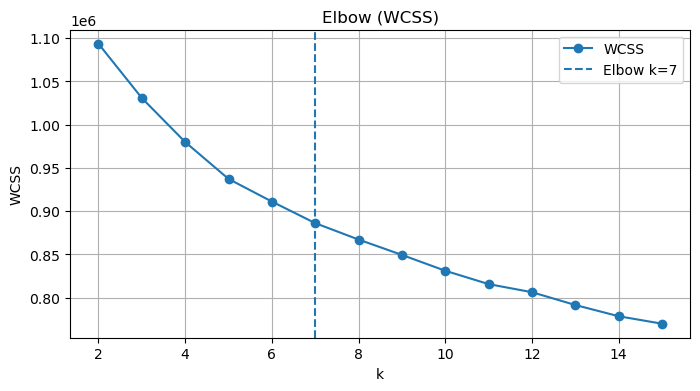

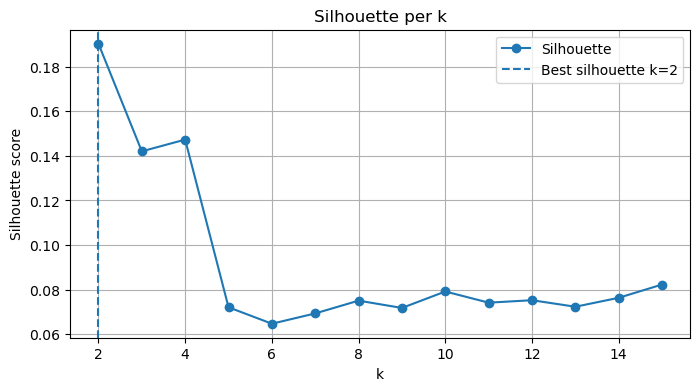

Elbow k: 7 | Best silhouette k: 2 | Selected k_opt: 7

✅ Assigned Structure_Cluster with k=7.
                                              SMILES  Structure_Cluster
0                                        ON=Cc1cscc1                  2
1  O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...                  5
2                                    [O-][n+]1ccccc1                  2
3  OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...                  5
4                                 CC(=O)c1ccc(cc1)Br                  2
✅ Clustered parquet saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/full_train_scaled_no_interaction.parquet


In [9]:
# -----------------------------
# 5) KMeans clustering
# -----------------------------
random_state = 0

k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

assert len(cluster_labels) == len(df_scaled), "Cluster labels length mismatch."

df_clustered = df_scaled.copy()
df_clustered["Structure_Cluster"] = cluster_labels

print(f"\n✅ Assigned Structure_Cluster with k={k_opt}.")
print(df_clustered[["SMILES", "Structure_Cluster"]].head())

# -----------------------------
# 6) Save clustered TRAIN parquet
# -----------------------------
artifacts_dir = Path.cwd() / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

clustered_path = artifacts_dir / "full_train_scaled_no_interaction.parquet"
df_clustered.to_parquet(clustered_path, index=False)

print("✅ Clustered parquet saved to:", clustered_path)


In [10]:
# classifier/ → MELTING_POINT_2026/
PROJECT_ROOT = Path.cwd().parent        # directory above a path: .../MELTING_POINT_2026

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

processed_dir = PROJECT_ROOT / "data_curation" / "processed_data"

train_path = PROJECT_ROOT / "Ro5" / "artifacts" / "full_train_scaled_no_interaction.parquet"
df_train = pd.read_parquet(train_path)

df_train.head()


,SMILES,MP,Type,Ro5,RDKit_SMR_VSA2,RDKit_Kappa2,MACCS_41,RDKit_SMR_VSA6,RDKit_SlogP_VSA5,RDKit_VSA_EState7,...,RDKit_fr_Ar_NH,RDKit_Chi4n,RDKit_PEOE_VSA12,RDKit_NumAliphaticRings,MACCS_101,RDKit_TPSA,RDKit_fr_ArN,RDKit_fr_SH,RDKit_NumHeteroatoms,Structure_Cluster
0,ON=Cc1cscc1,122.0,Train,1,-0.239453,-0.811915,-0.247167,-0.670027,-0.593429,-0.041376,...,-0.199183,-0.889538,-0.434742,-0.504875,-0.618592,-0.550322,-0.268728,-0.07374,-0.510997,2
1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,205.5,Train,1,-0.239453,-0.147094,-0.247167,-0.670027,1.554215,1.008411,...,-0.199183,3.464175,-0.434742,4.239993,1.616573,0.429088,-0.268728,-0.07374,-0.147901,5
2,[O-][n+]1ccccc1,64.0,Train,1,-0.239453,-1.079534,-0.247167,-0.670027,-0.815794,0.262521,...,-0.199183,-0.908687,-0.434742,-0.504875,-0.618592,-0.711607,-0.268728,-0.07374,-0.874093,2
3,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,146.0,Train,1,-0.239453,0.883762,-0.247167,-0.670027,3.410957,2.895269,...,-0.199183,3.927528,-0.434742,3.291019,1.616573,-0.903150,-0.268728,-0.07374,-1.237189,5
4,CC(=O)c1ccc(cc1)Br,51.0,Train,1,-0.239453,-0.658299,-0.247167,-0.670027,-0.125061,-0.326855,...,-0.199183,-0.729484,-0.434742,-0.504875,-0.618592,-0.993355,-0.268728,-0.07374,-0.874093,2


In [11]:
TARGET_COL = "MP"

exclude = {"SMILES", TARGET_COL, "Type", "Ro5", "Structure_Cluster"}
num_cols = df_train.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in num_cols if c not in exclude]

X = df_train[feature_cols].to_numpy(np.float32) 
y = df_train[TARGET_COL].to_numpy(np.float32)
y_strat = df_train["Structure_Cluster"].astype(str).to_numpy()

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=10)
folds = [(tr, va) for tr, va in skf.split(X, y_strat)]

print("Total samples:", len(X))
print("Num features:", X.shape[1])
print("Num folds:", len(folds))
print()

for i, (tr_idx, va_idx) in enumerate(folds):
    print(
        f"Fold {i:2d} | "
        f"Train: {len(tr_idx):4d} | "
        f"Val: {len(va_idx):4d}"
    )


Total samples: 12054
Num features: 101
Num folds: 10

Fold  0 | Train: 10848 | Val: 1206
Fold  1 | Train: 10848 | Val: 1206
Fold  2 | Train: 10848 | Val: 1206
Fold  3 | Train: 10848 | Val: 1206
Fold  4 | Train: 10849 | Val: 1205
Fold  5 | Train: 10849 | Val: 1205
Fold  6 | Train: 10849 | Val: 1205
Fold  7 | Train: 10849 | Val: 1205
Fold  8 | Train: 10849 | Val: 1205
Fold  9 | Train: 10849 | Val: 1205


In [12]:
import time
import numpy as np
from pathlib import Path

trial_times = []

def objective(trial):
    dropout_rate  = trial.suggest_float("dropout_rate",  0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay  = trial.suggest_float("weight_decay",  1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])

    h1 = trial.suggest_categorical("h1", [64, 96, 128, 160, 192, 224, 256])
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    hidden_layers = [h1, h2, h3]

    start = time.perf_counter()
    rmses = []

    for fold_idx, (tr_idx, val_idx) in enumerate(folds):
        X_train_scaled = X[tr_idx]
        y_train        = y[tr_idx]
        X_val_scaled   = X[val_idx]
        y_val          = y[val_idx]

        rmse, *_ = evaluate_fold(
            trial=trial,
            fold_idx=fold_idx,
            X_train_scaled=X_train_scaled,
            y_train=y_train,
            X_val_scaled=X_val_scaled,
            y_val=y_val,
            learning_rate=learning_rate,
            batch_size=batch_size,
            hidden_layers=hidden_layers,
            dropout_rate=dropout_rate,
            weight_decay=weight_decay,
            save_checkpoints=False,
            checkpoint_dir=None,   # <- no checkpoints
        )
        rmses.append(float(rmse))

    elapsed_min = (time.perf_counter() - start) / 60.0
    trial_times.append(elapsed_min)

    avg_rmse = float(np.mean(rmses))

    # Save for later plotting/analysis
    trial.set_user_attr("avg_rmse", avg_rmse)
    trial.set_user_attr("fold_rmses", rmses)
    trial.set_user_attr("elapsed_min", elapsed_min)

    print(f"Trial {trial.number} finished in {elapsed_min:.2f} minutes")
    print(f"Trial {trial.number}: Average RMSE = {avg_rmse:.4f}")

    return avg_rmse

def set_optuna_study(n_trials): 
    start_time = time.perf_counter()
    print("Setting up Optuna study...")
    
    # 1) Set up the Optuna study
    study = optuna.create_study(direction='minimize') #minimize return loss
    study.optimize(objective, n_trials=n_trials)  #CHANGE TO 100 AFTER TESTING
    
    # 2) Identify the best hyperparameters
    best_params = study.best_params #best_params holds the dropout, learning rate, and weight decay that gave the lowest best_val_loss
    print("Best hyperparameters:", best_params)
    
    end_time = time.perf_counter()
    elapsed_time = (end_time - start_time) / 60.0
    print(f"Optuna study completed in {elapsed_time:.2f} minutes")
    
    return best_params, study


device = torch.device("cpu")
best_params, study = set_optuna_study(n_trials=20)

[I 2026-02-09 04:54:59,018] A new study created in memory with name: no-name-e664bf36-ca57-4e89-8c11-4ed751554cdb


Setting up Optuna study...
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 144.3510 | Val Loss: 144.0411 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 137.4073 | Val Loss: 137.4309 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 126.8686 | Val Loss: 127.0178 | ES 0/30
[Fold 0] Epoch  150 | Train Loss: 112.2838 | Val Loss: 111.2885 | ES 0/30
[Fold 0] Epoch  200 | Train Loss: 93.3036 | Val Loss: 91.9304 | ES 0/30
[Fold 0] Epoch  250 | Train Loss: 73.2397 | Val Loss: 74.2338 | ES 2/30
[Fold 0] Epoch  300 | Train Loss: 57.1447 | Val Loss: 56.9680 | ES 9/30
[Fold 0] Epoch  350 | Train Loss: 53.3830 | Val Loss: 49.1486 | ES 4/30
[Fold 0] Epoch  400 | Train Loss: 52.6157 | Val Loss: 47.4737 | ES 23/30
[Fold 0] Early stopping  at epoch 407 (best Val Loss: 45.7798)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 143.5988 | Val Loss: 142.8740 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 135.6622 | Val Loss: 135.5774 | ES 2/30
[Fold 1] Epoch  100 | Train Loss: 123.1307 | Val Loss: 12

[I 2026-02-09 05:18:12,882] Trial 0 finished with value: 43.68763542175293 and parameters: {'dropout_rate': 0.2963652874954865, 'learning_rate': 1.8574470772185902e-05, 'weight_decay': 0.0003261209745169426, 'batch_size': 32, 'h1': 96}. Best is trial 0 with value: 43.68763542175293.


[Fold 9] Early stopping  at epoch 417 (best Val Loss: 41.9012)
Trial 0 finished in 23.23 minutes
Trial 0: Average RMSE = 43.6876
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 145.2358 | Val Loss: 144.5204 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 143.0570 | Val Loss: 142.9898 | ES 1/30
[Fold 0] Epoch  100 | Train Loss: 140.2341 | Val Loss: 140.1027 | ES 0/30
[Fold 0] Epoch  150 | Train Loss: 136.5370 | Val Loss: 136.4003 | ES 1/30
[Fold 0] Epoch  200 | Train Loss: 132.2964 | Val Loss: 132.3541 | ES 2/30
[Fold 0] Epoch  250 | Train Loss: 126.8474 | Val Loss: 126.8233 | ES 1/30
[Fold 0] Epoch  300 | Train Loss: 120.6662 | Val Loss: 120.4617 | ES 1/30
[Fold 0] Epoch  350 | Train Loss: 113.4862 | Val Loss: 114.1275 | ES 1/30
[Fold 0] Epoch  400 | Train Loss: 105.5863 | Val Loss: 103.7774 | ES 0/30
[Fold 0] Epoch  450 | Train Loss: 96.6296 | Val Loss: 96.1844 | ES 3/30
[Fold 0] Epoch  500 | Train Loss: 87.0218 | Val Loss: 85.8082 | ES 3/30
[Fold 0] Epoch  550 | Train Loss: 78.

[I 2026-02-09 05:38:38,952] Trial 1 finished with value: 61.84322967529297 and parameters: {'dropout_rate': 0.4739922756506951, 'learning_rate': 2.1647096322792022e-05, 'weight_decay': 0.001570501507894549, 'batch_size': 64, 'h1': 64}. Best is trial 0 with value: 43.68763542175293.


...

[Fold 9] Early stopping  at epoch 262 (best Val Loss: 35.7096)
Trial 17 finished in 16.98 minutes
Trial 17: Average RMSE = 37.2161
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 142.3698 | Val Loss: 140.8178 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 43.7550 | Val Loss: 38.1266 | ES 0/30
[Fold 0] Epoch  100 | Train Loss: 42.0423 | Val Loss: 37.2082 | ES 10/30
[Fold 0] Epoch  150 | Train Loss: 41.6153 | Val Loss: 37.9436 | ES 10/30
[Fold 0] Early stopping  at epoch 170 (best Val Loss: 36.7329)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 143.0305 | Val Loss: 140.6594 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 44.1764 | Val Loss: 38.1587 | ES 9/30
[Fold 1] Epoch  100 | Train Loss: 41.9572 | Val Loss: 36.4224 | ES 10/30
[Fold 1] Epoch  150 | Train Loss: 41.6381 | Val Loss: 37.1185 | ES 13/30
[Fold 1] Early stopping  at epoch 194 (best Val Loss: 35.9429)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 141.9259 | Val Loss: 138.6853 | ES 0/30
[Fold 2] Epoc

[I 2026-02-09 12:34:01,127] Trial 18 finished with value: 37.13337783813476 and parameters: {'dropout_rate': 0.33406345239144775, 'learning_rate': 0.00015705797047746374, 'weight_decay': 9.205106934115616e-06, 'batch_size': 16, 'h1': 192}. Best is trial 15 with value: 36.057390975952146.


[Fold 9] Early stopping  at epoch 161 (best Val Loss: 34.9963)
Trial 18 finished in 17.47 minutes
Trial 18: Average RMSE = 37.1334
Fold 0: Training on cpu
[Fold 0] Epoch    1 | Train Loss: 143.3367 | Val Loss: 142.0771 | ES 0/30
[Fold 0] Epoch   50 | Train Loss: 45.2251 | Val Loss: 38.5384 | ES 3/30
[Fold 0] Epoch  100 | Train Loss: 43.1296 | Val Loss: 37.6301 | ES 7/30
[Fold 0] Epoch  150 | Train Loss: 42.4139 | Val Loss: 37.2910 | ES 10/30
[Fold 0] Early stopping  at epoch 170 (best Val Loss: 36.9574)
Fold 1: Training on cpu
[Fold 1] Epoch    1 | Train Loss: 143.3038 | Val Loss: 141.4451 | ES 0/30
[Fold 1] Epoch   50 | Train Loss: 45.0731 | Val Loss: 37.6765 | ES 0/30
[Fold 1] Epoch  100 | Train Loss: 42.9820 | Val Loss: 36.9508 | ES 8/30
[Fold 1] Early stopping  at epoch 122 (best Val Loss: 36.5131)
Fold 2: Training on cpu
[Fold 2] Epoch    1 | Train Loss: 143.4318 | Val Loss: 140.3587 | ES 0/30
[Fold 2] Epoch   50 | Train Loss: 44.3521 | Val Loss: 38.2265 | ES 5/30
[Fold 2] Epoch  

[I 2026-02-09 12:40:42,232] Trial 19 finished with value: 37.12060394287109 and parameters: {'dropout_rate': 0.24737340967751317, 'learning_rate': 0.0004665768371448789, 'weight_decay': 1.956372293398463e-05, 'batch_size': 32, 'h1': 64}. Best is trial 15 with value: 36.057390975952146.


[Fold 9] Early stopping  at epoch 129 (best Val Loss: 35.7770)
Trial 19 finished in 6.69 minutes
Trial 19: Average RMSE = 37.1206
Best hyperparameters: {'dropout_rate': 0.241755182061781, 'learning_rate': 0.0001916656957834362, 'weight_decay': 9.43064786944659e-06, 'batch_size': 32, 'h1': 256}
Optuna study completed in 465.72 minutes


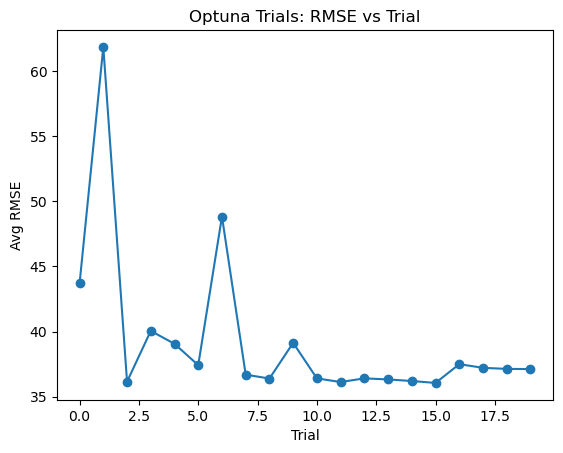

In [13]:
import matplotlib.pyplot as plt

df_trials = study.trials_dataframe(attrs=("number", "value", "user_attrs"))
rmse_by_trial = df_trials["value"].to_numpy()   # value == returned avg_rmse
trial_nums = df_trials["number"].to_numpy()

plt.figure()
plt.plot(trial_nums, rmse_by_trial, marker="o")
plt.xlabel("Trial")
plt.ylabel("Avg RMSE")
plt.title("Optuna Trials: RMSE vs Trial")
plt.show()

In [14]:
# Save the best parameters

print("Best Trial Number:", study.best_trial.number)
print("  RMSE:", study.best_value)
print("  Params:", study.best_params)

Best Trial Number: 15
  RMSE: 36.057390975952146
  Params: {'dropout_rate': 0.241755182061781, 'learning_rate': 0.0001916656957834362, 'weight_decay': 9.43064786944659e-06, 'batch_size': 32, 'h1': 256}


In [15]:
from pathlib import Path
import torch
import pandas as pd

# BASE and artifacts_dir should already be defined (same script as before)
BASE = Path.cwd()  # Ro5
artifacts_dir = BASE / "artifacts"

# ---------- Directories for final best models + checkpoints ----------
best_models_dir = artifacts_dir / "general_best_models_no_interaction"
best_models_dir.mkdir(parents=True, exist_ok=True)

final_ckpt_dir = BASE / "checkpoints_general_best_no_interaction"
final_ckpt_dir.mkdir(parents=True, exist_ok=True)

# Make sure best_params exists (from your Optuna study: best_params, study = set_optuna_study(...))
print("Best hyperparameters from Optuna:", best_params)

# Helper to derive hidden layers from best_params (same logic as in objective)
def build_hidden_layers_from_best(best_params):
    h1 = best_params["h1"]
    h2 = max(h1 // 2, 4)
    h3 = max(h2 // 2, 2)
    return [h1, h2, h3]

hidden_layers = build_hidden_layers_from_best(best_params)
dropout_rate  = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
weight_decay  = best_params["weight_decay"]
batch_size    = best_params["batch_size"]

print("Using hidden_layers:", hidden_layers)
print("dropout:", dropout_rate, "| lr:", learning_rate, "| wd:", weight_decay, "| batch_size:", batch_size)

# To keep track of metrics across folds
final_fold_metrics = []

# ---------- Final training loop for all folds (using `folds`, X, y) ----------
# Assumes you already defined:
#   X, y, folds = [(tr_idx, val_idx), ...] earlier (same as in `objective`)
for fold_idx, (tr_idx, val_idx) in enumerate(folds):
    print(f"\n==================== Final training for fold {fold_idx} ====================")

    # Slice the global X, y using the same folds as during Optuna
    X_train_scaled = X[tr_idx]
    y_train        = y[tr_idx]
    X_val_scaled   = X[val_idx]
    y_val          = y[val_idx]

    # Train this fold with the best hyperparameters
    rmse, r2, q2, model, train_losses, val_losses, stop_epoch = evaluate_fold(
        trial=None,                    # not needed for final run
        fold_idx=fold_idx,
        X_train_scaled=X_train_scaled,
        y_train=y_train,
        X_val_scaled=X_val_scaled,
        y_val=y_val,
        hidden_layers=hidden_layers,
        learning_rate=learning_rate,
        batch_size=batch_size,
        dropout_rate=dropout_rate,
        weight_decay=weight_decay,
        max_epochs=10**9,              # will stop via early-stopping anyway
        patience=30,
        min_delta=0.0,
        save_checkpoints=True,         # save checkpoints for this BEST config
        checkpoint_dir=final_ckpt_dir, # root; evaluate_fold will create fold_{k}/ inside
        save_every_n_epochs=15
    )

    # ---------- Save the final (best) model for this fold ----------
    model_path = best_models_dir / f"general_best_fold_{fold_idx}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "hidden_layers": hidden_layers,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "fold_idx": fold_idx,
            "rmse": rmse,
            "r2": r2,
            "q2": q2,
        },
        model_path,
    )
    print(f"[Fold {fold_idx}] Saved best model to: {model_path}")

    # store metrics
    final_fold_metrics.append(
        {
            "Fold": fold_idx,
            "RMSE": rmse,
            "R2": r2,
            "Q2": q2,
            "Stop_Epoch": stop_epoch,
            "Model_Path": str(model_path),
        }
    )

# ---------- Save a summary CSV of all folds ----------
metrics_df = pd.DataFrame(final_fold_metrics)
metrics_path = best_models_dir / "general_best_models_no_interaction_summary.csv"
metrics_df.to_csv(metrics_path, index=False)
print("\n✅ Saved summary of best models across folds to:", metrics_path)
print(metrics_df)


Best hyperparameters from Optuna: {'dropout_rate': 0.241755182061781, 'learning_rate': 0.0001916656957834362, 'weight_decay': 9.43064786944659e-06, 'batch_size': 32, 'h1': 256}
Using hidden_layers: [256, 128, 64]
dropout: 0.241755182061781 | lr: 0.0001916656957834362 | wd: 9.43064786944659e-06 | batch_size: 32

==================== Final training for fold 0 ====================
Fold 0: Training on cpu
Checkpoints will be saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/checkpoints_general_best_no_interaction/fold_0
[Fold 0] Regular checkpoint saved at epoch 1 - RMSE: 141.0046
[Fold 0] Epoch    1 | Train Loss: 142.4050 | Val Loss: 140.6060 | ES 0/30
[Fold 0] Regular checkpoint saved at epoch 15 - RMSE: 65.7796
[Fold 0] Regular checkpoint saved at epoch 30 - RMSE: 39.5206
[Fold 0] Regular checkpoint saved at epoch 45 - RMSE: 38.1314
[Fold 0] Epoch   50 | Train Loss: 39.2920 | Val Loss: 37.8231 | ES 1/30
[Fold 0] Regular checkpoint saved at epoch 60 - RMSE: 37.5795
[Fold 0

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

from sklearn.cluster import KMeans
from kneed import KneeLocator


processed_dir = PROJECT_ROOT / "data_curation" / "processed_data"

data_path = processed_dir / "final_dataset_no_interaction.parquet"
df = pd.read_parquet(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)


# -----------------------------
# 1) Filter Test
# -----------------------------

df_test = df[df["Type"].astype(str).str.lower() == "test"].copy()

# -----------------------------
# 2) Feature columns (MUST match scaler)
# -----------------------------
NON_FEATURES = ["SMILES", "MP", "Type", "Ro5"]
feature_cols = [c for c in df.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

# -----------------------------
# 3) Load saved scaler
# -----------------------------
scaler_path = "../data_curation/processed_data/df_final_scaler_no_interaction.pkl"
scaler = joblib.load(scaler_path)
print("Loaded scaler from:", scaler_path)

# -----------------------------
# 4) Build TRAIN matrix and scale
# -----------------------------
X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
X_scaled = scaler.transform(X_test)

# Scaled dataframe
df_scaled = df_test.copy()
df_scaled[feature_cols] = X_scaled

print("X_scaled shape:", X_scaled.shape)
print("df_scaled shape:", df_scaled.shape)

Loaded: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/data_curation/processed_data/final_dataset_no_interaction.parquet
Shape: (17220, 105)
Loaded scaler from: ../data_curation/processed_data/df_final_scaler_no_interaction.pkl
X_scaled shape: (5166, 101)
df_scaled shape: (5166, 105)


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


X_scaled shape: (5166, 101)
df_scaled shape: (5166, 105)


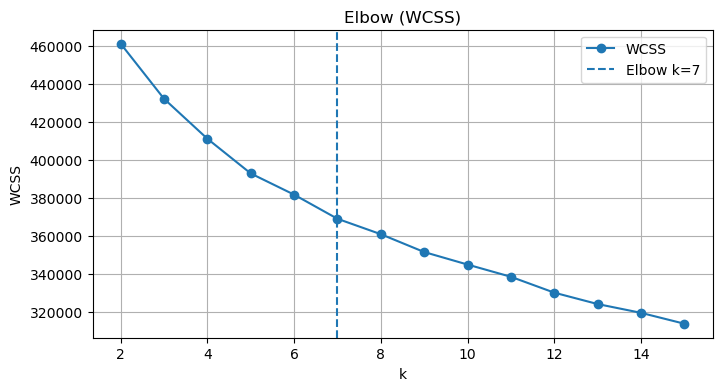

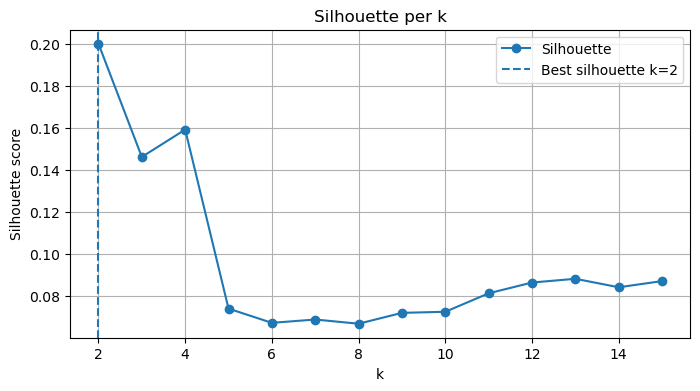

Elbow k: 7 | Best silhouette k: 2 | Selected k_opt: 7

✅ Assigned Structure_Cluster with k=7.
                                                  SMILES  Structure_Cluster
12054  [O-][N+](=O)c1c(C)c(C(=O)C)c(c(c1C(C)(C)C)[N+]...                  0
12055                                CN(NC(=O)CCC(=O)O)C                  2
12056                  CCCCc1ccc(cc1)NC(=O)Oc1ccc(cc1)OC                  2
12057                    OC(=O)COCCN1C(=O)c2c(C1=O)cccc2                  0
12058                                    CCCCCCCCCCCCCCC                  5
✅ Clustered parquet saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/full_test_scaled_no_interaction.parquet


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


# 6) Transform TRAIN features -> scaled
X_scaled = scaler.transform(X_test).astype(np.float32)

# Optional: create a scaled dataframe version (keeps SMILES/MP/Type/Ro5 unchanged)
df_scaled = df_test.copy()
df_scaled[feature_cols] = X_scaled

print("X_scaled shape:", X_scaled.shape)
print("df_scaled shape:", df_scaled.shape)

random_state = 0

k_opt = find_optimal_clusters(X_scaled=X_scaled, max_k=15, random_state=random_state, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

# sanity check alignment
assert len(cluster_labels) == len(df_scaled), "Cluster labels length != df_scaled rows (mismatch)."

df_clustered = df_scaled.copy()
df_clustered["Structure_Cluster"] = cluster_labels

print(f"\n✅ Assigned Structure_Cluster with k={k_opt}.")
print(df_clustered[["SMILES", "Structure_Cluster"]].head())

# -----------------------------
# 4) Save clustered parquet (+ optional kmeans)
# -----------------------------
clustered_path = artifacts_dir / "full_test_scaled_no_interaction.parquet"
df_clustered.to_parquet(clustered_path, index=False)
print("✅ Clustered parquet saved to:", clustered_path)

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import joblib

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from NN_model import ImprovedNN  # adjust if needed

# --------------------
# PATHS
# --------------------
BASE = Path.cwd()  # wherever your notebook is running
CKPT_PTH = BASE / "artifacts/general_best_models_no_interaction/general_best_fold_9.pt"

TEST_SCALED = BASE / "artifacts/full_test_scaled_no_interaction.parquet"   
OUT_PRED_CSV = BASE / "artifacts/test_general_predictions_no_interaction.csv"

# --------------------
# MODEL PARAMETERS (must match checkpoint architecture)
# --------------------
HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATE = 0.241755182061781  # must match best params used for that checkpoint

# --------------------
# Load scaled test set
# --------------------
df_test = pd.read_parquet(TEST_SCALED)

NON_FEATURES = ["SMILES", "MP", "Type", "Ro5", "Structure_Cluster"]
feature_cols = [c for c in df_test.columns if c not in NON_FEATURES]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_test[c])]

# Optional: enforce deterministic order (better: load exact feature list from training manifest)
#feature_cols = sorted(feature_cols)

X_test = df_test[feature_cols].to_numpy(dtype=np.float32)
y_true = df_test["MP"].to_numpy(dtype=float)
smiles = df_test["SMILES"].astype(str).to_numpy()

print("Test rows:", len(df_test))
print("Features:", X_test.shape[1])

# --------------------
# Recreate model + load checkpoint
# --------------------
device = torch.device("cpu")

model = ImprovedNN(
    input_size=X_test.shape[1],
    hidden_layers=HIDDEN_LAYERS,
    dropout_rate=DROPOUT_RATE
).to(device)

loaded = torch.load(CKPT_PTH, map_location=device)

if isinstance(loaded, dict) and "model_state_dict" in loaded:
    model.load_state_dict(loaded["model_state_dict"], strict=True)
else:
    model.load_state_dict(loaded, strict=True)

model.eval()

# --------------------
# Predict
# --------------------
X_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    y_pred = model(X_tensor).squeeze().cpu().numpy().astype(float)

# --------------------
# Evaluate
# --------------------
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae  = float(mean_absolute_error(y_true, y_pred))
r2   = float(r2_score(y_true, y_pred))

print("\n=== TEST METRICS ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R^2 : {r2:.4f}")

# --------------------
# Save predictions
# --------------------
out_df = pd.DataFrame({
    "SMILES": smiles,
    "Type": df_test["Type"].astype(str).to_numpy(),
    "Ro5": df_test["Ro5"].to_numpy(),
    "exp MP": y_true,
    "pred MP": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

OUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"\nSaved predictions -> {OUT_PRED_CSV}")

Test rows: 5166
Features: 101

=== TEST METRICS ===
RMSE: 36.2233
MAE : 26.9185
R^2 : 0.7411

Saved predictions -> /Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_general_predictions_no_interaction.csv


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_49108/2330389668.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(CKPT_PTH, map_location=d

In [22]:
import pandas as pd
out_df = pd.read_csv("/Users/sdl5_mp/Documents/GitHub/melting_point_2026/Ro5/artifacts/test_general_predictions_no_interaction.csv")

In [23]:
out_df

,SMILES,Type,Ro5,exp MP,pred MP,error,abs_error
0,[O-][N+](=O)c1c(C)c(C(=O)C)c(c(c1C(C)(C)C)[N+]...,Test,1,135.5,124.633804,-10.866196,10.866196
1,CN(NC(=O)CCC(=O)O)C,Test,1,154.5,134.352539,-20.147461,20.147461
2,CCCCc1ccc(cc1)NC(=O)Oc1ccc(cc1)OC,Test,1,143.0,103.242546,-39.757454,39.757454
3,OC(=O)COCCN1C(=O)c2c(C1=O)cccc2,Test,1,128.0,137.932388,9.932388,9.932388
4,CCCCCCCCCCCCCCC,Test,1,10.0,21.516865,11.516865,11.516865
...,...,...,...,...,...,...,...
5161,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,Test,1,226.0,195.315063,-30.684937,30.684937
5162,COc1cc(OC)cc(c1C#N)OC,Test,1,142.0,114.812286,-27.187714,27.187714
5163,OCCCCCCCCCCc1ccccc1,Test,1,36.0,28.953310,-7.046690,7.046690
5164,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,Test,1,159.0,188.720734,29.720734,29.720734


In [25]:
rmse_total = np.sqrt(np.mean(out_df["error"] ** 2))
print(f"Total RMSE (all): {rmse_total:.3f}")

df_ro5 = out_df[out_df["Ro5"] == 1]
rmse_ro5 = np.sqrt(np.mean(df_ro5["error"] ** 2))
print(f"RMSE (Ro5): {rmse_ro5:.3f}")

df_bro5 = out_df[out_df["Ro5"] == 0]
rmse_bro5 = np.sqrt(np.mean(df_bro5["error"] ** 2))
print(f"RMSE (bRo5): {rmse_bro5:.3f}")


Total RMSE (all): 36.223
RMSE (Ro5): 35.831
RMSE (bRo5): 51.101


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

(0.0, 500.0)

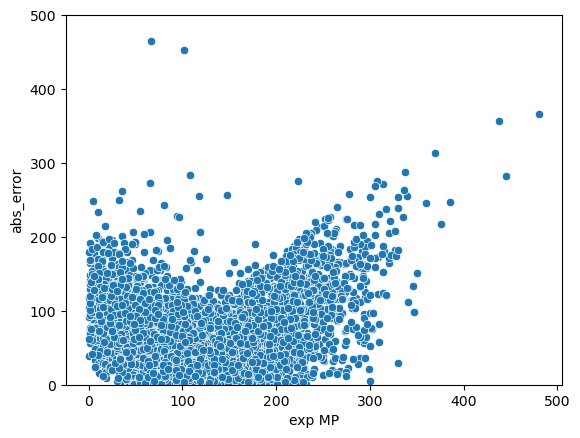

In [18]:
sns.scatterplot(x=out_df['exp MP'], y=out_df['abs_error'])
plt.ylim(0,500)

In [ ]:
# Plotting optuna trial with RMSE

import matplotlib.pyplot as plt
import pandas as pd

# Collect data from your study
records = []
for t in study.trials:
    if t.value is not None:  # skip failed/pruned trials
        records.append({"trial": t.number, "rmse": t.value})

df = pd.DataFrame(records)

plt.figure(figsize=(8,5))
plt.plot(df["trial"], df["rmse"], marker="o")
plt.title("Optuna Trials vs Mean RMSE (10-Fold Average)")
plt.xlabel("Trial Number")
plt.ylabel("Average RMSE")
plt.grid(True)
plt.show()